In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
arthur_full, fs = sf.read('data/arthur_full.wav')

ad = AudioDevice(fs)

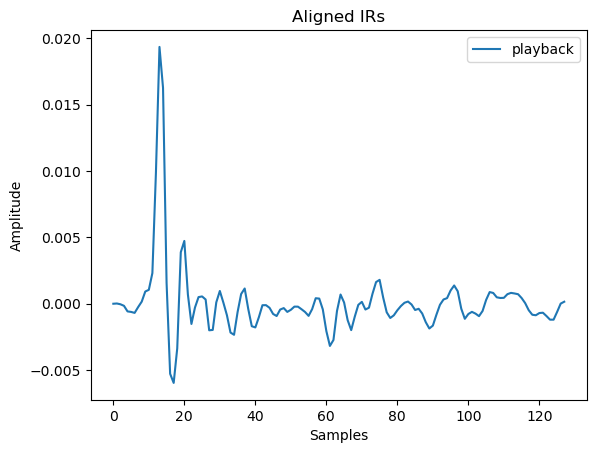

In [3]:
ir_len = 128
panel_to_err_cm = 9

error_ir, _ = measure_ir(ad)
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IRs')
plt.legend()
plt.show()

In [4]:
arthur_repeated = np.tile(arthur, 100)

rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
)

Lag from cross-correlation: 4476
Delay from device: 4312


db_redux: -2.0963514


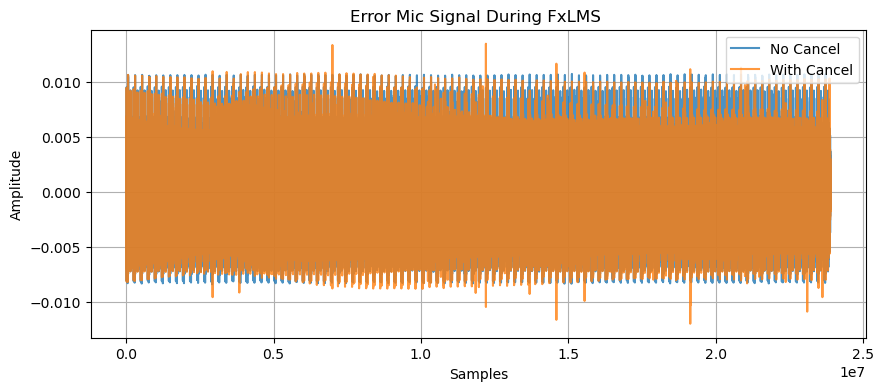

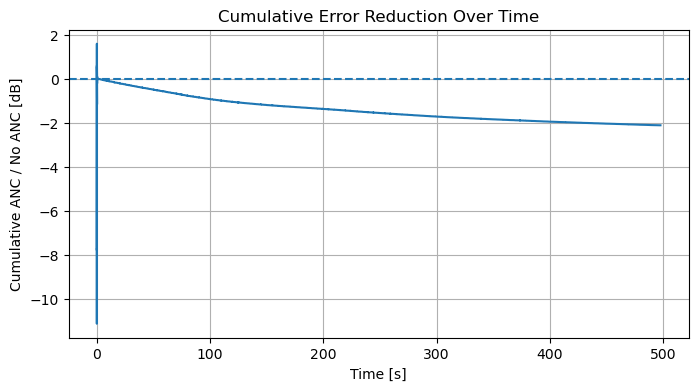

In [5]:
rt.reset(rt.system_lag, block_size=128, filter_order=2048)

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

In [6]:
arthur_repeated = np.tile(arthur, 50)

rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
)

Lag from cross-correlation: 4476
Delay from device: 4312


db_redux: -2.8897903


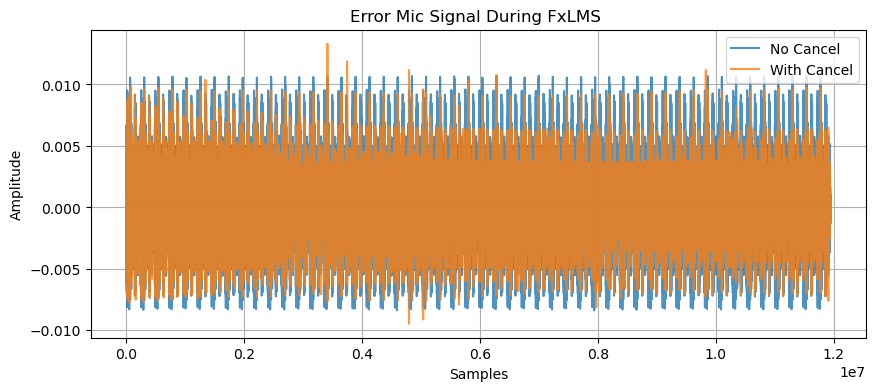

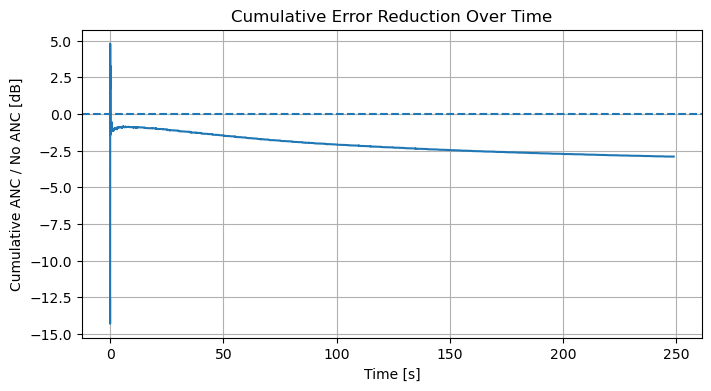

In [7]:
rt.reset(rt.system_lag, block_size=128, filter_order=2048)

rt.w[104] = 0.5
seed = rt.w.copy()

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

In [8]:
full = rt.w.copy()
delta = rt.w - seed

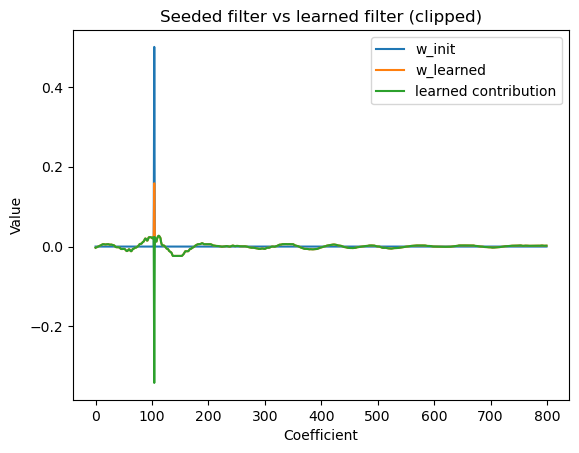

In [11]:
plt.plot(seed[:800], label='w_init')
plt.plot(full[:800], label='w_learned')
plt.plot(delta[:800], label='learned contribution')

plt.title('Seeded filter vs learned filter (clipped)')
plt.xlabel('Coefficient')
plt.ylabel('Value')
plt.legend()
plt.show()

In [12]:
for w_test in [seed, delta, full]:
    
    rt.reset(rt.system_lag)
    rt.w = w_test

    error, cancel, *_ = rt.run(
        source_gain=1.0,
        cancel_gain=.2,
        fx=False,
        nlms=False,
        clean_source=True,
        step_fn=0.0,
        leak=0.0,
        max_norm=0.0,
    )

    print('db_redux:', rt.db_reduction)

db_redux: -0.6418966
db_redux: -2.3930883
db_redux: -3.7717059


In [13]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_full,
    ir=panel_ir,
)

Lag from cross-correlation: 4473
Delay from device: 4312


seeded: True db_redux: -0.91643465
seeded: False db_redux: -0.9169876
seeded: True db_redux: -0.90171754
seeded: False db_redux: -0.74066377
seeded: True db_redux: -0.7447297
seeded: False db_redux: -0.43262947
seeded: True db_redux: -0.5950836
seeded: False db_redux: -0.29331183


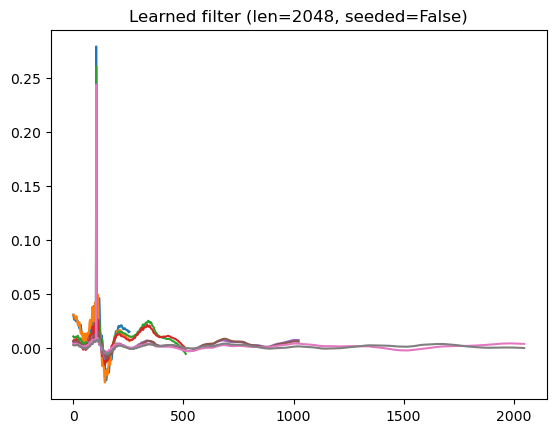

In [17]:
filter_orders = [256, 512, 1024, 2048]
use_seed = [True, False]

for filt in filter_orders:
    for seed in use_seed:
        rt.reset(rt.system_lag, block_size=128, filter_order=filt)
        
        if seed:
            rt.w[104] = .5

        error, cancel, *_ = rt.run(
            source_gain=1.0,
            cancel_gain=.2,
            fx=True,
            nlms=True,
            clean_source=True,
            step_fn=3e-5,
            leak=1e-7,
            max_norm=1.0,
        )

        print('seeded:', seed, 'db_redux:', rt.db_reduction)

        plt.plot(rt.w)
        plt.title(f"Learned filter (len={filt}, seeded={seed})")

In [18]:
arthur_repeated = np.tile(arthur, 50)

rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
)

Lag from cross-correlation: 4470
Delay from device: 4312


db_redux: -3.3130434


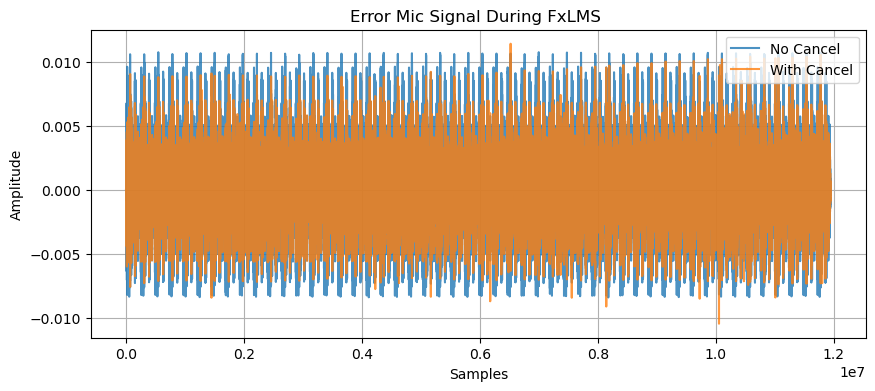

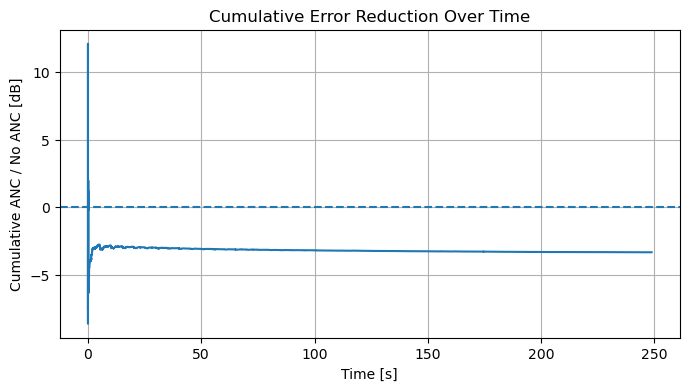

In [19]:
rt.reset(rt.system_lag, block_size=128, filter_order=2048)

rt.w[96] = 0.25
rt.w[104] = 0.5
rt.w[136] = -0.2
rt.w[144] = -0.33

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

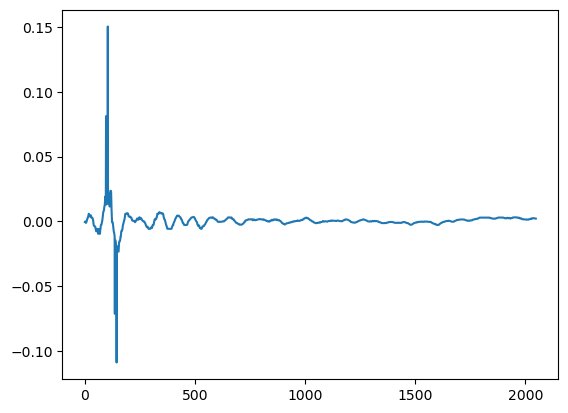

In [20]:
plt.plot(rt.w)

filt_len: 512 seeded: True db_redux: -1.3580464
filt_len: 512 seeded: False db_redux: 0.30780888
filt_len: 1024 seeded: True db_redux: -2.7463963
filt_len: 1024 seeded: False db_redux: -2.7102652
filt_len: 2048 seeded: True db_redux: -3.4814916
filt_len: 2048 seeded: False db_redux: -2.3872616


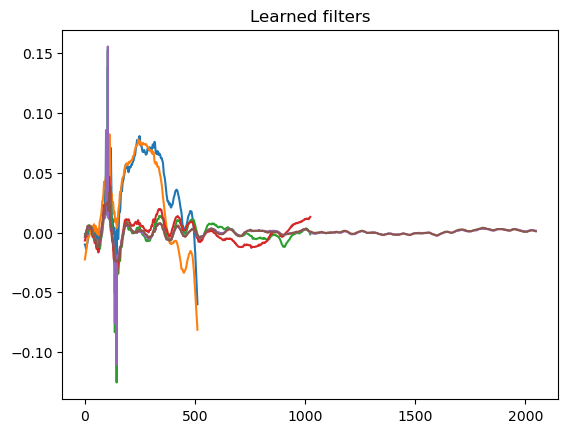

In [21]:
filter_orders = [512, 1024, 2048]
use_seed = [True, False]

for filt in filter_orders:
    for seed in use_seed:
        rt.reset(rt.system_lag, block_size=128, filter_order=filt)

        if seed:
            rt.w[96] = 0.25
            rt.w[104] = 0.5
            rt.w[136] = -0.2
            rt.w[144] = -0.33

        error, cancel, *_ = rt.run(
            source_gain=1.0,
            cancel_gain=.2,
            fx=True,
            nlms=True,
            clean_source=True,
            step_fn=1e-4,
            leak=1e-7,
            max_norm=1.0,
        )

        print('filt_len:', filt, 'seeded:', seed, 'db_redux:', rt.db_reduction)
        plt.plot(rt.w, label=f'{filt}, {"seeded" if seed else ""}')

plt.title(f"Learned filters")
plt.show()

db_redux: -3.6465738


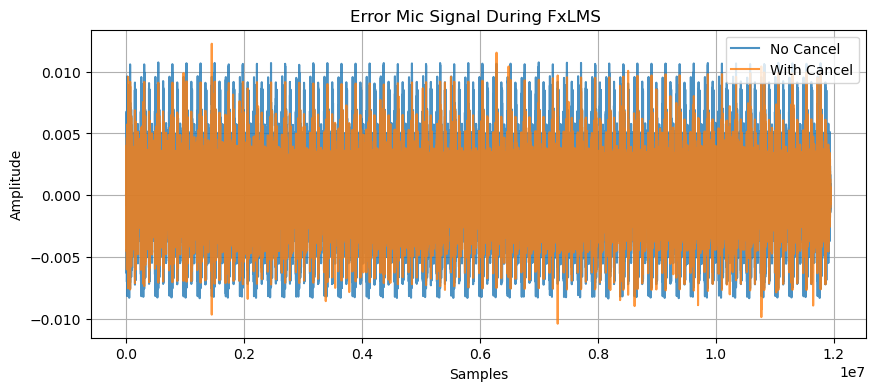

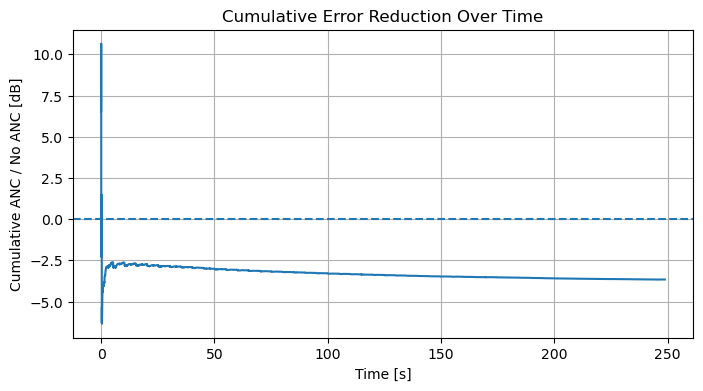

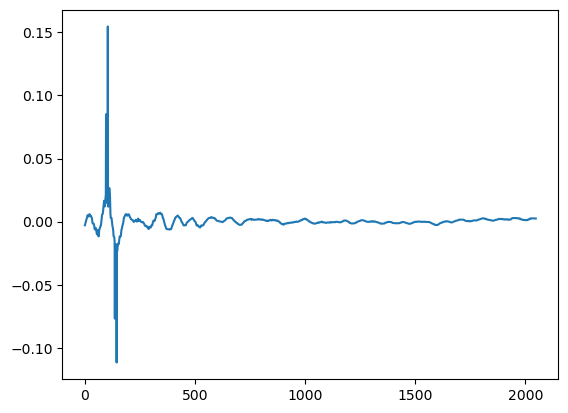

In [22]:
rt.reset(rt.system_lag, block_size=128, filter_order=2048)

rt.w[96] = 0.25
rt.w[104] = 0.5
rt.w[136] = -0.2
rt.w[144] = -0.33

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

w_frozen = rt.w.copy()

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()
plt.plot(rt.w)

In [23]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_full,
    ir=panel_ir,
)

Lag from cross-correlation: 4468
Delay from device: 4312


db_redux: -1.6436205


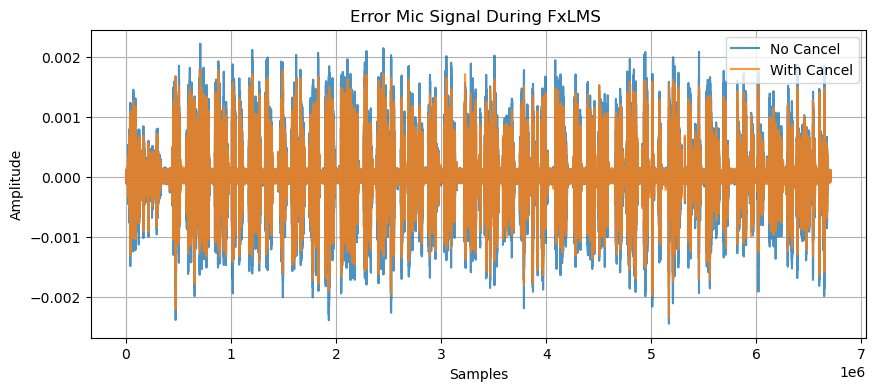

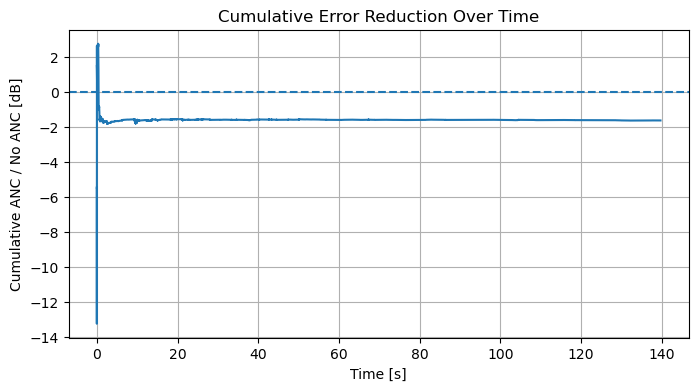

In [24]:
rt.reset(rt.system_lag, block_size=128, filter_order=2048)
rt.w = w_frozen

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=False,
    nlms=False,
    clean_source=True,
    step_fn=0.0,
    leak=0.0,
    max_norm=0.0,
)

print('db_redux:', rt.db_reduction)

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()

In [26]:
arthur_repeated = np.tile(arthur, 50)

rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
)

Lag from cross-correlation: 4470
Delay from device: 4312


db_redux: -0.52551055


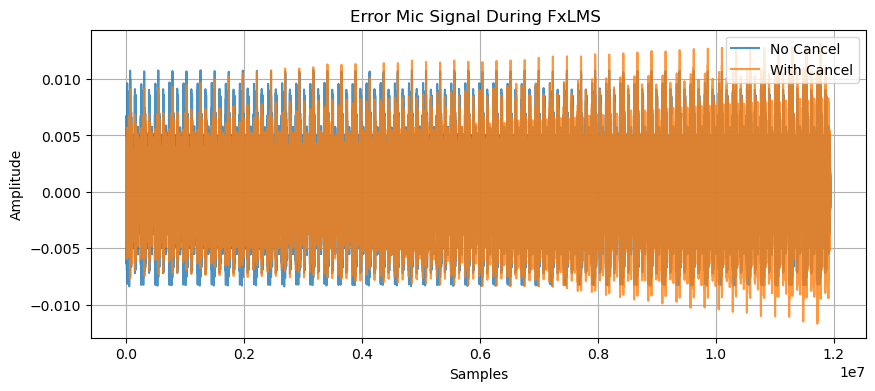

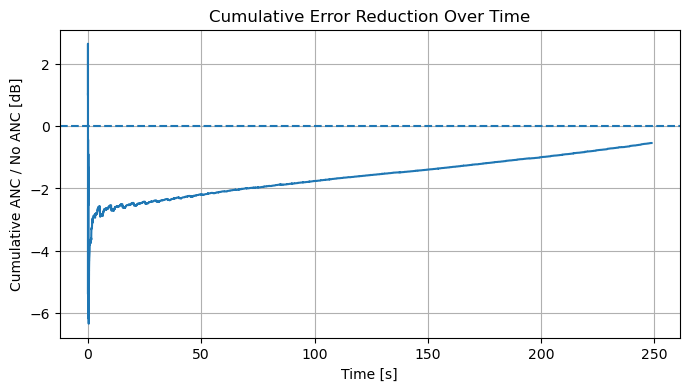

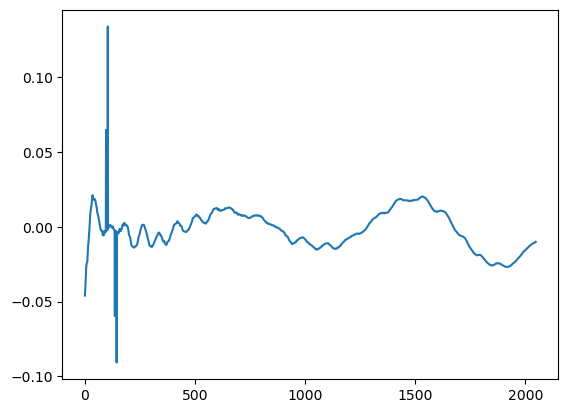

In [27]:
rt.reset(rt.full_lag, block_size=128, filter_order=2048)

rt.w[96] = 0.25
rt.w[104] = 0.5
rt.w[136] = -0.2
rt.w[144] = -0.33

error, cancel, *_ = rt.run(
    source_gain=1.0,
    cancel_gain=.2,
    fx=True,
    nlms=True,
    clean_source=True,
    step_fn=1e-4,
    leak=1e-7,
    max_norm=1.0,
)

print('db_redux:', rt.db_reduction)

w_frozen = rt.w.copy()

rt.plot_error_mic()
rt.plot_cumulative_error_reduction()
plt.plot(rt.w)